# LeetCode #477: Total Hamming Distance

https://leetcode.com/problems/total-hamming-distance/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (all pairs)** | $O(n^2)$ | $O(1)$ |
| **Per-Bit Population Count** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (all pairs)
Compute the Hamming distance for every pair $(i, j)$ by XOR-ing them and counting set bits. With $n$ numbers this is $\binom{n}{2} = O(n^2)$ pair operations.

### Optimal: Per-Bit Population Count ★
For each of the 32 bit positions, count how many numbers have a 1 there (call it $k$). The contribution to total Hamming distance from that position is $k \times (n - k)$: each 1-number pairs with each 0-number to contribute distance 1. Sum across all 32 positions in a single $O(n)$ pass.

**Why this is better than Brute Force:** Reduces $O(n^2)$ pair comparisons to $O(n)$ bit counts — for $n = 10^4$, that is $10^8$ vs $10^4$ operations.

**Constraints:**
* `1 <= nums.length <= 10^4`
* `0 <= nums[i] <= 10^9`

## Solutions

### C#

In [ ]:
public int TotalHammingDistance(int[] nums) {
    int total = 0, n = nums.Length;
    // For each bit position, count how many numbers have that bit set
    for (int bit = 0; bit < 32; bit++) {
        int ones = 0;
        foreach (int num in nums) {
            ones += (num >> bit) & 1;
        }
        // Each 1-bit pairs with each 0-bit to contribute one unit of Hamming distance
        total += ones * (n - ones);
    }
    return total;
}

### Python

In [ ]:
def totalHammingDistance(self, nums: list[int]) -> int:
    n = len(nums)
    total = 0
    # Each bit position contributes ones*(n-ones) to the total Hamming distance
    for bit in range(32):
        ones = sum((num >> bit) & 1 for num in nums)
        total += ones * (n - ones)
    return total

### Go

In [ ]:
func totalHammingDistance(nums []int) int {
    total, n := 0, len(nums)
    for bit := 0; bit < 32; bit++ {
        ones := 0
        // Count numbers with a 1 at this bit position
        for _, num := range nums {
            ones += (num >> bit) & 1
        }
        // Pairs between 1-bits and 0-bits each contribute distance 1
        total += ones * (n - ones)
    }
    return total
}

### Rust

In [ ]:
pub fn total_hamming_distance(nums: Vec<i32>) -> i32 {
    let n = nums.len() as i32;
    let mut total = 0;
    for bit in 0..32 {
        // Count how many numbers have a 1 at this bit position
        let ones: i32 = nums.iter().map(|&x| (x >> bit) & 1).sum();
        // Hamming pairs at this bit = (1-count) * (0-count)
        total += ones * (n - ones);
    }
    total
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [4, 14, 2]
4=0100, 14=1110, 2=0010. Bit 1: ones=3 → 3×0=0. Bit 2: ones=2 → 2×1=2. Bit 3: ones=1 → 1×2=2. Bit 4 onward: all 0. Total = **6**. Matches brute force: d(4,14)=2, d(4,2)=2, d(14,2)=2.

**2. Slightly Complex**
**Input:** nums = [1, 3, 6]
1=001, 3=011, 6=110. Per bit: bit 0 → ones=2, 2×1=2; bit 1 → ones=2, 2×1=2; bit 2 → ones=1, 1×2=2. Total = **6**. All three pairwise distances are 2 each.

**3. Edge Case: Time Factor**
**Input:** 10,000 numbers each equal to $10^9 \approx 2^{30}$
All numbers identical → every bit has all-ones or all-zeros → contribution = ones×(n-ones) = n×0 = 0. Total = **0**. Still scans 32×10,000 = 320,000 elements, showing linear time.

**4. Edge Case: Space Factor**
**Input:** nums = [0, 1]
Minimum input, two numbers. Bit 0: ones=1 → 1×1=1. All other bits: 0. Total = **1**. Only two scalar counters used, $O(1)$ space.

**5. Almost-Impossible but Plausible**
**Input:** 5,000 zeros followed by 5,000 nines ($10^9$, all 30 bits set)
For each of the 30 significant bits: ones=5,000, n-ones=5,000 → 25,000,000 per bit. Total $\approx 30 \times 25 \times 10^6 = 750{,}000{,}000$ — fits in a 32-bit signed integer without overflow ($< 2^{31}-1$).

### Infographic

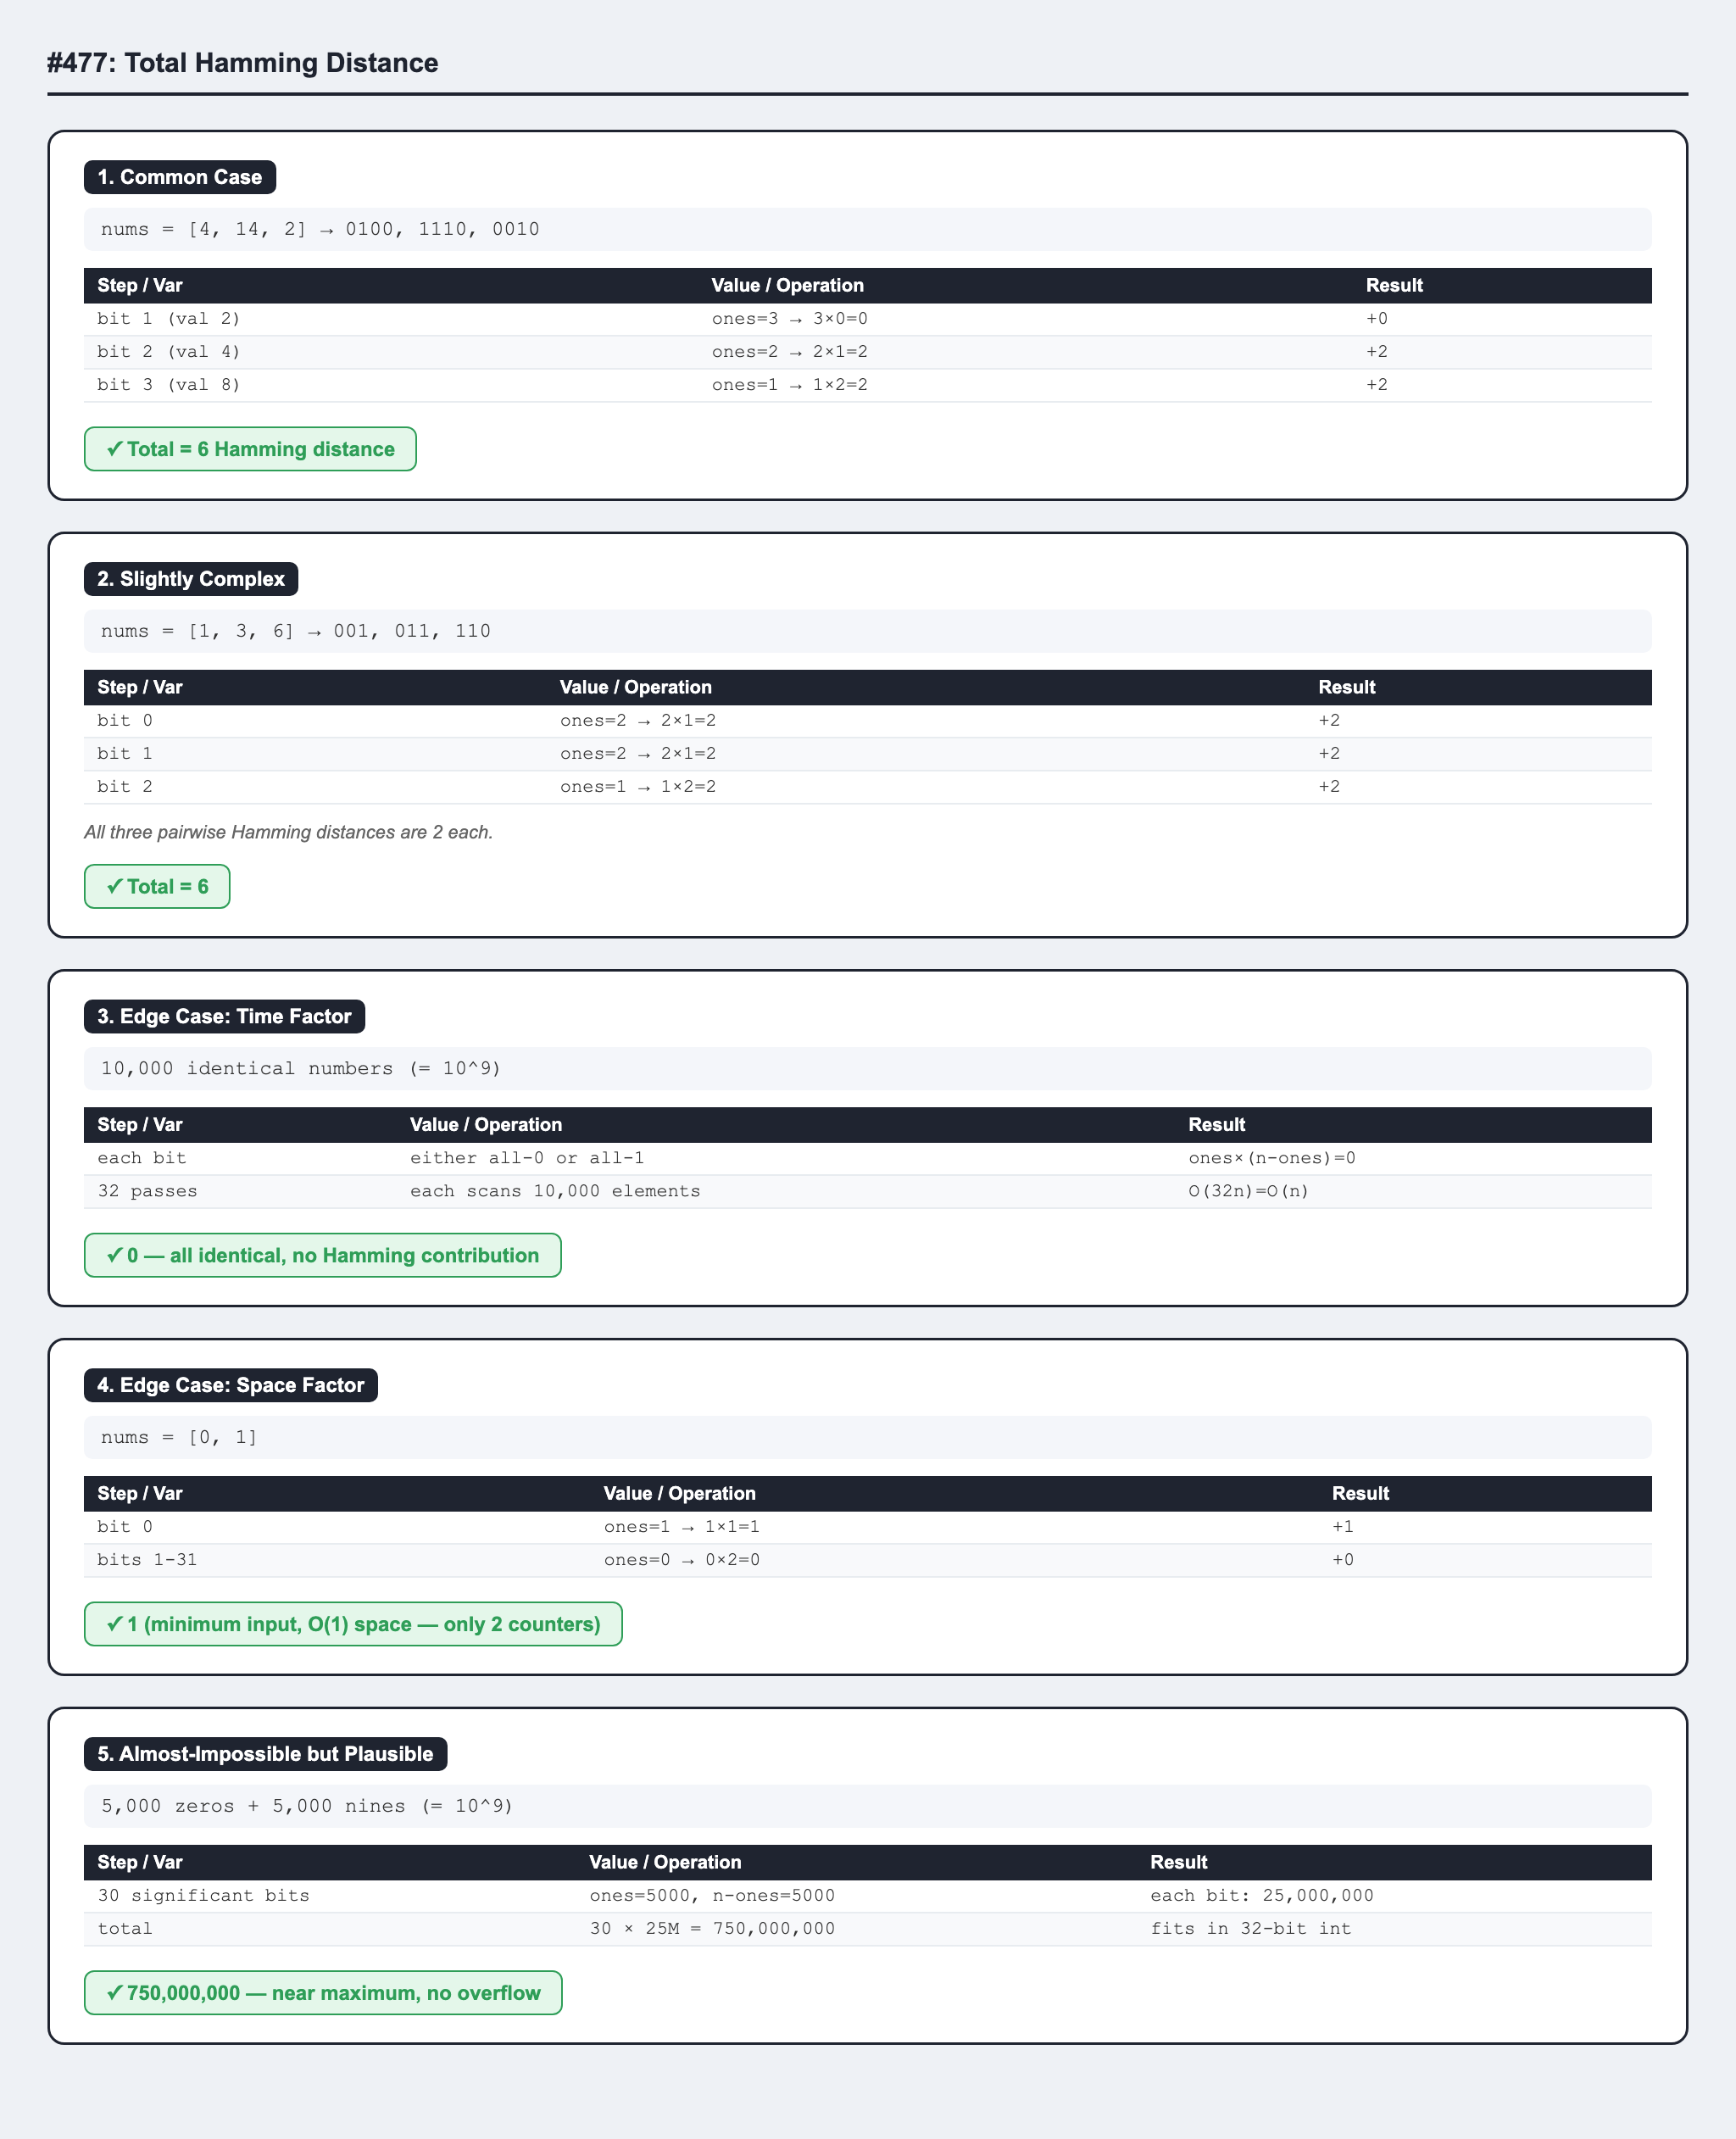